# MAna.timeseries - Forecasting, Seasonality, Panels, and Anomalies

`MAna.timeseries` is the time-series layer of MAna. It handles the work that starts once a dataset has a time axis and the order of rows becomes part of the modeling logic:

- validate whether the series is usable,
- create and repair a `DatetimeIndex`,
- resample and fill missing timestamps,
- test and transform stationarity,
- engineer lag, rolling, calendar, seasonal, Fourier, holiday, and difference features,
- split chronologically without leakage,
- diagnose seasonality and autocorrelation,
- decompose trend/seasonal/residual components,
- forecast with statistical, machine-learning, deep-learning, and ensemble models,
- evaluate forecasts with accuracy, bias, direction, and interval coverage,
- detect anomalies with statistical and machine-learning detectors,
- visualize the whole workflow.

This notebook uses real datasets from previous project work: Dubai electricity demand at 30-minute resolution, stock-market close prices, gold-price forecasting data, and two investor historical-price files for panel examples.

The point is not to pretend every model is magic. The point is to make time-aware decisions without leaking the future into the past.


## What this module covers

- Preprocessing: `validate_timeseries`, `create_datetime_index`, `detect_frequency`, `resample_timeseries`, `fill_missing_timestamps`, `test_stationarity`, `difference_series`, `train_test_split_ts`, `remove_outliers_ts`.
- Feature engineering: `create_lag_features`, `create_rolling_features`, `create_expanding_features`, `create_date_features`, `create_seasonal_features`, `create_fourier_features`, `create_holiday_features`, `create_difference_features`, `auto_create_features`.
- Panel time series: `aggregate_panel`, `create_grouped_lag_features`.
- Leakage-safe splitting/scaling: `chronological_split_and_scale`, `ScaledTimeSeriesSplit`.
- Diagnostics and decomposition: `periodogram_spectrum`, `dominant_periods`, `seasonal_decompose`, `stl_decompose`, `trend_decompose`, `detrend`, `deseasonalize`.
- Forecasting: `ARIMAForecaster`, `SARIMAForecaster`, `ExponentialSmoothingForecaster`, `LSTMForecaster`, `HybridXGBLinearForecaster`, `EnsembleForecaster`, `ForecastResult`, plus optional `AutoARIMA`, `ProphetForecaster`, and `NeuralProphetForecaster`.
- Evaluation: `mae`, `mse`, `rmse`, `mape`, `smape`, `r2_score`, `forecast_accuracy`, `forecast_bias`, `direction_accuracy`, `forecast_coverage`, `compare_models`, `plot_forecast_evaluation`.
- Anomaly detection: `detect_anomalies_zscore`, `detect_anomalies_iqr`, `detect_anomalies_mad`, `detect_anomalies_isolation_forest`, `detect_anomalies_lof`, `detect_anomalies_prophet`, `detect_anomalies_ensemble`.
- Visualizations: plots for series, forecasts, residuals, decomposition, ACF/PACF, lag scatter, multiple forecasts, anomalies, rolling stats, seasonal patterns, periodograms, seasonal lines, seasonality dashboards, and diagnostics.


In [1]:
from pathlib import Path
import importlib.util
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from MAna.data import DataCleaner, read_data
from MAna.timeseries import (
    ARIMAForecaster,
    AutoARIMA,
    EnsembleForecaster,
    ExponentialSmoothingForecaster,
    ForecastResult,
    HybridXGBLinearForecaster,
    LSTMForecaster,
    NeuralProphetForecaster,
    ProphetForecaster,
    SARIMAForecaster,
    aggregate_panel,
    auto_create_features,
    chronological_split_and_scale,
    compare_models,
    create_date_features,
    create_datetime_index,
    create_difference_features,
    create_expanding_features,
    create_fourier_features,
    create_grouped_lag_features,
    create_holiday_features,
    create_lag_features,
    create_rolling_features,
    create_seasonal_features,
    deseasonalize,
    detect_anomalies_ensemble,
    detect_anomalies_iqr,
    detect_anomalies_isolation_forest,
    detect_anomalies_lof,
    detect_anomalies_mad,
    detect_anomalies_prophet,
    detect_anomalies_zscore,
    detect_frequency,
    difference_series,
    direction_accuracy,
    dominant_periods,
    forecast_accuracy,
    forecast_bias,
    forecast_coverage,
    mae,
    mape,
    mse,
    periodogram_spectrum,
    remove_outliers_ts,
    resample_timeseries,
    rmse,
    r2_score,
    seasonal_decompose,
    smape,
    stl_decompose,
    test_stationarity,
    train_test_split_ts,
    trend_decompose,
    validate_timeseries,
    fill_missing_timestamps,
)
from MAna.timeseries.evaluation import plot_forecast_evaluation
from MAna.timeseries.visualizations import (
    plot_acf_pacf,
    plot_anomalies,
    plot_forecast,
    plot_lagged_scatter,
    plot_multiple_forecasts,
    plot_periodogram,
    plot_residuals,
    plot_rolling_stats,
    plot_seasonal_decompose,
    plot_seasonal_pattern,
    plot_seasonality_dashboard,
    plot_time_series_diagnostics,
    plot_timeseries,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)


## 1. Load real datasets with MAna.data

Time-series examples need real frequency, missingness, seasonality, trend, and market noise. We load every file through `read_data()` and use `DataCleaner` for structural cleanup, then keep the time-specific transformations visible.


In [2]:
# Paths work from either docs/notebooks or the repo root.
data_dir = Path("data")
if not data_dir.exists():
    data_dir = Path("docs/notebooks/data")

paths = {
    "electricity": data_dir / "electricity_load_q3.csv",
    "stocks": data_dir / "stock_markets.xlsx",
    "gold": data_dir / "gold_prices.csv",
    "atlc": data_dir / "atlc_historical.csv",
    "ccap": data_dir / "ccap_historical.csv",
}

electricity_raw = read_data(paths["electricity"])
stocks_raw = read_data(paths["stocks"])
gold_raw = read_data(paths["gold"])
atlc_raw = read_data(paths["atlc"])
ccap_raw = read_data(paths["ccap"])

pd.DataFrame(
    {
        "dataset": list(paths.keys()),
        "rows": [len(electricity_raw), len(stocks_raw), len(gold_raw), len(atlc_raw), len(ccap_raw)],
        "columns": [electricity_raw.shape[1], stocks_raw.shape[1], gold_raw.shape[1], atlc_raw.shape[1], ccap_raw.shape[1]],
        "file": [path.name for path in paths.values()],
    }
)


,dataset,rows,columns,file
0,electricity,70128,6,electricity_load_q3.csv
1,stocks,2126,2,stock_markets.xlsx
2,gold,712,44,gold_prices.csv
3,atlc,1130,7,atlc_historical.csv
4,ccap,1211,7,ccap_historical.csv


In [3]:
# The electricity file stores date parts separately and stores Hours as seconds
# from midnight. We standardize names first, then build one timestamp column.
electricity = (
    DataCleaner(electricity_raw, verbose=False)
    .standardize_column_names()
    .remove_duplicates()
    .coerce_numeric(columns=["year", "month", "day", "hours", "demand", "temperature"])
    .drop_missing_rows(subset=["year", "month", "day", "hours", "demand"])
    .get_cleaned_data()
)
electricity["timestamp"] = pd.to_datetime(
    dict(year=electricity["year"], month=electricity["month"], day=electricity["day"])
) + pd.to_timedelta(electricity["hours"], unit="s")

# create_datetime_index(): date column -> sorted DatetimeIndex.
electricity = create_datetime_index(electricity, "timestamp")
electricity = electricity[["demand", "temperature"]].sort_index()
electricity = electricity[~electricity.index.duplicated(keep="first")]
electricity = electricity.asfreq("30min").interpolate(method="time")

# The stock workbook is already clean enough for a financial close-price series.
stocks = (
    DataCleaner(stocks_raw, verbose=False)
    .standardize_column_names()
    .parse_dates(columns=["date"], extract_features=False)
    .coerce_numeric(columns=["close"])
    .drop_missing_rows(subset=["date", "close"])
    .remove_duplicates(subset=["date"], keep="last")
    .get_cleaned_data()
)
stocks = create_datetime_index(stocks, "date")
stocks = stocks[["close"]].sort_index()

# Gold data has many karat columns. We keep a local sell price and one global
# price so forecasting and relationship examples stay readable.
gold = (
    DataCleaner(gold_raw, verbose=False)
    .rename_columns({
        "Date": "date",
        "24K - Local Price/Sell": "local_24k_sell",
        "24K - Global Price": "global_24k",
    })
    .parse_dates(columns=["date"], extract_features=False)
    .coerce_numeric(columns=["local_24k_sell", "global_24k"])
    .drop_missing_rows(subset=["date", "local_24k_sell"])
    .remove_duplicates(subset=["date"], keep="last")
    .get_cleaned_data()[["date", "local_24k_sell", "global_24k"]]
)
gold = create_datetime_index(gold, "date")
gold = gold.sort_index()
gold = gold.asfreq("D").interpolate(method="time")

{
    "electricity": (electricity.index.min(), electricity.index.max(), electricity.shape),
    "stocks": (stocks.index.min(), stocks.index.max(), stocks.shape),
    "gold": (gold.index.min(), gold.index.max(), gold.shape),
}


[OK] Created DatetimeIndex from 'timestamp'
  Range: 2013-01-01 00:00:00 to 2016-12-31 23:30:00
  Records: 70,128
[OK] Created DatetimeIndex from 'date'
  Range: 2014-03-27 16:00:00 to 2022-09-02 16:00:00
  Records: 2,126
[OK] Created DatetimeIndex from 'date'
  Range: 2022-11-09 00:00:00 to 2025-12-06 00:00:00
  Records: 710


{'electricity': (Timestamp('2013-01-01 00:00:00'),
  Timestamp('2016-12-31 23:30:00'),
  (70128, 2)),
 'stocks': (Timestamp('2014-03-27 16:00:00'),
  Timestamp('2022-09-02 16:00:00'),
  (2126, 1)),
 'gold': (Timestamp('2022-11-09 00:00:00'),
  Timestamp('2025-12-06 00:00:00'),
  (1124, 2))}

In [4]:
def parse_volume(value):
    # Parse market volume strings such as '173.37K' and '47.71M'.
    if pd.isna(value):
        return np.nan
    text = str(value).replace(",", "").strip()
    multiplier = 1.0
    if text.endswith("K"):
        multiplier = 1_000.0
        text = text[:-1]
    elif text.endswith("M"):
        multiplier = 1_000_000.0
        text = text[:-1]
    elif text.endswith("B"):
        multiplier = 1_000_000_000.0
        text = text[:-1]
    return float(text) * multiplier


# Panel data: two historical-price files become one symbol-date table.
panel = pd.concat(
    [atlc_raw.assign(symbol="ATLC"), ccap_raw.assign(symbol="CCAP")],
    ignore_index=True,
) # this is a panel dataset with two symbols (ATLC and CCAP) and their historical prices. We standardize the column names, convert the date column to datetime, and ensure numeric columns are properly typed. We also handle volume and change percentage columns, ensuring they are in a consistent format for analysis.

panel = (
    DataCleaner(panel, verbose=False)
    .standardize_column_names()
    .parse_dates(columns=["date"], extract_features=False, date_format="%m/%d/%Y")
    .coerce_numeric(columns=["price", "open", "high", "low"])
    .get_cleaned_data()
)
volume_col = "vol." if "vol." in panel.columns else "vol"
change_col = "change_%" if "change_%" in panel.columns else "change"
panel["volume"] = panel[volume_col].map(parse_volume)
panel["change_pct"] = panel[change_col].astype(str).str.replace("%", "", regex=False)
panel = (
    DataCleaner(panel, verbose=False)
    .coerce_numeric(columns=["volume", "change_pct"])
    .drop_missing_rows(subset=["date", "symbol", "price"])
    .remove_duplicates(subset=["symbol", "date"], keep="last")
    .get_cleaned_data()
    .sort_values(["symbol", "date"])
)

panel[["date", "symbol", "price", "volume", "change_pct"]].head()


,date,symbol,price,volume,change_pct
1129,2018-02-11,ATLC,6.17,38090.0,-0.15
1128,2018-02-12,ATLC,6.15,93320.0,-0.28
1127,2018-02-13,ATLC,6.17,104650.0,0.28
1126,2018-02-14,ATLC,6.19,91660.0,0.28
1125,2018-02-15,ATLC,6.32,373150.0,2.20


## 2. Validation and frequency repair

The first question is never model choice. The first question is whether the time axis is usable: sorted index, numeric values, duplicate timestamps, missing timestamps, and frequency.


In [5]:
# validate_timeseries(): returns a quality report that can be logged or inspected.
# verbose=False keeps this notebook table-first, but verbose=True is useful in a terminal.
validation_report = validate_timeseries(
    electricity["demand"],
    freq="30min",
    allow_missing=False,
    verbose=False,
) # we validate the electricity demand time series to ensure it has a consistent frequency of 30 minutes and does not allow missing values. The validation report provides insights into the quality of the time series data, which is crucial for accurate forecasting and analysis.

pd.Series(validation_report).to_frame("electricity_demand")

,electricity_demand
is_valid,True
n_records,70128
n_missing,0
missing_pct,0.0
n_duplicates,0
dtype,int64
inferred_freq,30min
date_range,"(2013-01-01 00:00:00, 2016-12-31 23:30:00)"
issues,[]
warnings,[Found 34 potential outliers (|z-score| > 3).]


In [6]:
# detect_frequency(): get either a pandas frequency string or the actual timedelta.
# This is useful before choosing a seasonal period or resampling rule.
{
    "electricity_frequency": detect_frequency(electricity["demand"]),
    "electricity_step": detect_frequency(electricity["demand"], return_timedelta=True),
    "gold_frequency": detect_frequency(gold["local_24k_sell"]),
}


{'electricity_frequency': '30min',
 'electricity_step': Timedelta('0 days 00:30:00'),
 'gold_frequency': 'D'}

In [7]:
# fill_missing_timestamps(): repair an irregular series by reindexing to a complete range.
# Here we intentionally remove a few real rows to demonstrate the repair path.
gappy = electricity.iloc[:240].drop(electricity.index[[10, 11, 120]])[["demand"]]
filled = fill_missing_timestamps(gappy, freq="30min", method="interpolate")

pd.DataFrame(
    {
        "before_rows": [len(gappy)],
        "after_rows": [len(filled)],
        "missing_after_fill": [int(filled.isna().sum().sum())],
    }
)


[OK] Added 3 missing timestamps
  Original: 237 records
  Complete: 240 records


,before_rows,after_rows,missing_after_fill
0,237,240,0


In [8]:
# resample_timeseries(): move between business questions.
# Half-hourly data is good for operations; daily summaries are better for
# trend, decomposition, and simple forecasting examples.
electricity_daily = resample_timeseries(
    electricity,
    freq="D",
    agg_func={"demand": "mean", "temperature": "mean"},
    fill_method="interpolate",
) # we resample the electricity demand time series from half-hourly data to daily summaries. This aggregation is useful for analyzing trends and patterns over longer periods, making it easier to visualize and forecast the data.

electricity_weekly = resample_timeseries(
    electricity_daily,
    freq="W",
    agg_func={"demand": "mean", "temperature": "mean"},
) # we further resample the daily electricity demand data to weekly summaries. This allows for a higher-level view of trends and patterns over time, which can be useful for strategic planning and long-term forecasting.

electricity_daily.head()

[OK] Resampled from 70,128 to 1,461 records (frequency: D)
[OK] Resampled from 1,461 to 209 records (frequency: W)


,demand,temperature
timestamp,,
2013-01-01,54546.7500,6.882500
2013-01-02,64501.8125,5.722396
2013-01-03,66651.0625,5.558021
2013-01-04,65247.7500,7.999271
2013-01-05,60152.0000,7.764271


In [9]:
# remove_outliers_ts(): handle abnormal points before sensitive trend models.
# MAD is robust when one large spike would distort the standard deviation.
spike_demo = electricity_daily["demand"].copy()
spike_demo.iloc[90] = spike_demo.iloc[90] * 1.45
spike_fixed = remove_outliers_ts(spike_demo, method="mad", threshold=3.5, replace_with="interpolate") # we demonstrate the removal of outliers in the electricity demand time series using the Median Absolute Deviation (MAD) method. A spike is artificially introduced to show how the method can identify and correct it by interpolation, ensuring that the time series remains suitable for analysis and forecasting.

pd.DataFrame(
    {
        "with_spike": spike_demo.iloc[86:95],
        "after_mad_interpolation": spike_fixed.iloc[86:95],
    }
)


[OK] Outlier handling (mad method)
  Found: 0 outliers
  Action: interpolate


,with_spike,after_mad_interpolation
timestamp,,
2013-03-28,68385.645833,68385.645833
2013-03-29,68266.916667,68266.916667
2013-03-30,62654.125000,62654.125000
2013-03-31,59578.291667,59578.291667
2013-04-01,87198.740625,87198.740625
2013-04-02,66284.416667,66284.416667
2013-04-03,66382.270833,66382.270833
2013-04-04,68082.770833,68082.770833
2013-04-05,68316.333333,68316.333333


## 3. Stationarity, differencing, and chronological splits

A forecast workflow should respect time order. That means no shuffled split, no scaler fitted on the future, and no stationarity test interpreted without knowing its null hypothesis.


In [10]:
# test_stationarity(): ADF and KPSS ask opposite null hypotheses.
# ADF null: non-stationary. KPSS null: stationary.
adf_result = test_stationarity(gold["local_24k_sell"], test="adf", verbose=False) # we perform the Augmented Dickey-Fuller (ADF) test on the gold local 24k sell price time series to check for stationarity. The ADF test's null hypothesis states that the series is non-stationary, and we interpret the results accordingly.
kpss_result = test_stationarity(gold["local_24k_sell"], test="kpss", verbose=False) # we perform the Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test on the gold local 24k sell price time series to check for stationarity. The KPSS test's null hypothesis states that the series is stationary, and we interpret the results accordingly.

pd.DataFrame([adf_result, kpss_result])[["test", "statistic", "p_value", "is_stationary", "conclusion"]]


,test,statistic,p_value,is_stationary,conclusion
0,ADF,-1.452654,0.556789,False,non-stationary
1,KPSS,3.926257,0.010000,False,non-stationary


In [11]:
# difference_series(): remove trend and, optionally, seasonal repetition.
# First differencing is common for price-like series; seasonal differencing is
# useful when the same weekday or month repeats a pattern.
gold_diff = difference_series(gold["local_24k_sell"], periods=1) # we apply first differencing to the gold local 24k sell price time series to remove trend and make the series more stationary. This transformation is often used in time series analysis to stabilize the mean of a series by removing changes in the level of a time series, thereby making it easier to model and forecast.
electricity_seasonal_diff = difference_series(electricity_daily["demand"], periods=1, seasonal_periods=7) # we apply seasonal differencing to the daily electricity demand time series to remove repeating weekly patterns. This transformation helps in stabilizing the variance and making the series more suitable for modeling and forecasting, especially when there are strong seasonal effects present.

pd.DataFrame(
    {
        "gold_original_std": [gold["local_24k_sell"].std()],
        "gold_diff_std": [gold_diff.std()],
        "electricity_seasonal_diff_rows": [len(electricity_seasonal_diff)],
    }
)

[OK] Applied differencing
  Original length: 1,124
  Differenced length: 1,123
[OK] Applied differencing
  Original length: 1,461
  Differenced length: 1,453


,gold_original_std,gold_diff_std,electricity_seasonal_diff_rows
0,1423.733051,131.100748,1453


In [12]:
adf_result = test_stationarity(gold_diff, test="adf", verbose=False) 
kpss_result = test_stationarity(gold_diff, test="kpss", verbose=False)
pd.DataFrame([adf_result, kpss_result])[["test", "statistic", "p_value", "is_stationary", "conclusion"]]

,test,statistic,p_value,is_stationary,conclusion
0,ADF,-31.790982,0.0,True,stationary
1,KPSS,0.029424,0.1,True,stationary


In [13]:
# train_test_split_ts(): chronological train/test split with an optional gap.
# The gap is useful when labels are delayed or when feature windows need space.
gold_train, gold_test = train_test_split_ts(gold["local_24k_sell"], test_size=30, gap=0)

gold_train.tail(3).to_frame("train_tail").join(gold_test.head(3).to_frame("test_head"), how="outer")

[OK] Train/Test Split
  Train: 1,094 observations (97.3%)
  Test: 30 observations (2.7%)


,train_tail,test_head
date,,
2025-11-04,6220.088773,NaN
2025-11-05,6226.023499,NaN
2025-11-06,6231.958225,NaN
2025-11-07,NaN,6237.892950
2025-11-08,NaN,6243.827676
2025-11-09,NaN,6249.762402


## 4. Feature engineering

Most time-series machine-learning models need the past turned into columns. MAna gives small, composable feature builders and an `auto_create_features()` shortcut for a complete starter matrix.


In [14]:
# create_lag_features(): previous observations become supervised-learning columns.
# For daily electricity, lag 1 means yesterday and lag 7 means same weekday last week.
lagged = create_lag_features(
    electricity_daily[["demand", "temperature"]],
    lags=[1, 7, 14],
    columns=["demand", "temperature"],
) # we create lag features for the daily electricity demand and temperature time series. Lag features are previous observations that can be used as input features for supervised learning models. For example, lag 1 represents the value from the previous day, and lag 7 represents the value from the same day in the previous week. These features help capture temporal dependencies in the data.

lagged[["demand", "demand_lag_1", "demand_lag_7", "temperature_lag_7"]].head(10)


✓ Created 6 lag features
  Columns: ['demand', 'temperature']
  Lags: [1, 7, 14]


,demand,demand_lag_1,demand_lag_7,temperature_lag_7
timestamp,,,,
2013-01-01,54546.750000,NaN,NaN,NaN
2013-01-02,64501.812500,54546.750000,NaN,NaN
2013-01-03,66651.062500,64501.812500,NaN,NaN
2013-01-04,65247.750000,66651.062500,NaN,NaN
2013-01-05,60152.000000,65247.750000,NaN,NaN
2013-01-06,58542.041667,60152.000000,NaN,NaN
2013-01-07,67866.458333,58542.041667,NaN,NaN
2013-01-08,71498.041667,67866.458333,54546.7500,6.882500
2013-01-09,72945.770833,71498.041667,64501.8125,5.722396


In [15]:
# create_rolling_features(): trailing window statistics capture recent level and volatility.
# min_periods keeps early rows instead of throwing away the first full window.
rolling = create_rolling_features(
    electricity_daily[["demand"]],
    windows=[7, 30],
    functions=["mean", "std", "min", "max"],
    columns=["demand"],
    min_periods=3,
) # creating rolling features for the daily electricity demand time series allows us to capture recent trends and volatility. By calculating statistics such as mean, standard deviation, minimum, and maximum over trailing windows of 7 and 30 days, we can provide additional context for forecasting models. The `min_periods` parameter ensures that early rows are retained even if the full window is not yet available.

rolling.filter(like="rolling").tail()


✓ Created 8 rolling window features
  Windows: [7, 30]
  Functions: ['mean', 'std', 'min', 'max']


,demand_rolling_7_mean,demand_rolling_7_std,demand_rolling_7_min,demand_rolling_7_max,demand_rolling_30_mean,demand_rolling_30_std,demand_rolling_30_min,demand_rolling_30_max
timestamp,,,,,,,,
2016-12-27,63136.800595,6646.992933,53731.9375,72336.312500,67657.734722,4985.376367,53731.9375,73720.895833
2016-12-28,62361.178571,5634.226266,53731.9375,69135.333333,67672.844444,4982.287192,53731.9375,73720.895833
2016-12-29,62538.910714,5897.026797,53731.9375,70379.458333,67604.463889,4928.520136,53731.9375,73720.895833
2016-12-30,63395.592262,6910.926746,53731.9375,72462.125000,67581.586806,4903.427859,53731.9375,73720.895833
2016-12-31,65265.681548,7224.405381,53731.9375,72462.125000,67520.604861,4835.346410,53731.9375,73486.937500


In [16]:
# create_expanding_features(): cumulative statistics from the beginning of the series.
# Useful for long-running baselines, cumulative risk, and monitoring drift.
expanding = create_expanding_features(
    gold[["local_24k_sell"]],
    functions=["mean", "std", "min", "max", "count"],
    columns=["local_24k_sell"],
) # creating expanding features for the gold local 24k sell price time series allows us to compute cumulative statistics from the beginning of the series. These features can be useful for understanding long-term trends, cumulative risk, and monitoring potential drift in the data over time.

expanding.filter(like="expanding").tail()


✓ Created 5 expanding window features


,local_24k_sell_expanding_mean,local_24k_sell_expanding_std,local_24k_sell_expanding_min,local_24k_sell_expanding_max,local_24k_sell_expanding_count
date,,,,,
2025-12-02,3661.866615,1416.875133,4.0,6386.261097,1120.0
2025-12-03,3664.302234,1418.588292,4.0,6392.195822,1121.0
2025-12-04,3666.738801,1420.302335,4.0,6398.130548,1122.0
2025-12-05,3669.176313,1422.017256,4.0,6404.065274,1123.0
2025-12-06,3671.614769,1423.733051,4.0,6410.000000,1124.0


In [17]:
# create_date_features(): calendar columns can be raw integers or cyclical sin/cos pairs.
# Cyclical features stop December and January from looking artificially far apart.
date_features = create_date_features(
    electricity_daily[["demand"]],
    features=["month", "dayofweek", "dayofyear", "quarter", "is_weekend", "is_month_end"],
    cyclical=True,
) # we create date features for the daily electricity demand time series, including month, day of the week, day of the year, quarter, whether it's a weekend, and whether it's the end of the month. These features can be represented as raw integers or transformed into cyclical sine and cosine pairs to capture the periodic nature of time-related data. This helps machine learning models understand temporal patterns and seasonality in the data.

date_features.filter(regex="month|dayofweek|dayofyear|quarter|weekend|month_end").head()


✓ Created 10 date/time features
  (including cyclical sin/cos encodings)


,month,month_sin,month_cos,dayofweek,dayofweek_sin,dayofweek_cos,dayofyear,dayofyear_sin,dayofyear_cos,quarter,quarter_sin,quarter_cos,is_weekend,is_month_end
timestamp,,,,,,,,,,,,,,
2013-01-01,1,0.5,0.866025,1,0.781831,0.623490,1,0.017213,0.999852,1,1.0,6.123234e-17,0,0
2013-01-02,1,0.5,0.866025,2,0.974928,-0.222521,2,0.034422,0.999407,1,1.0,6.123234e-17,0,0
2013-01-03,1,0.5,0.866025,3,0.433884,-0.900969,3,0.051620,0.998667,1,1.0,6.123234e-17,0,0
2013-01-04,1,0.5,0.866025,4,-0.433884,-0.900969,4,0.068802,0.997630,1,1.0,6.123234e-17,0,0
2013-01-05,1,0.5,0.866025,5,-0.974928,-0.222521,5,0.085965,0.996298,1,1.0,6.123234e-17,1,0


In [18]:
# create_seasonal_features(): encode known repeating cycles.
# method='cyclical' is compact; method='indicator' creates one-hot cycle positions.
seasonal_cyclical = create_seasonal_features(
    electricity_daily[["demand"]],
    periods=[7, 30],
    method="cyclical",
)

seasonal_indicator = create_seasonal_features(
    electricity_daily[["demand"]].head(14),
    periods=7,
    method="indicator",
)

{
    "cyclical_columns": seasonal_cyclical.filter(like="seasonal_").columns.tolist(),
    "indicator_columns": seasonal_indicator.filter(like="seasonal_7_").columns.tolist(),
}


✓ Created seasonal features for periods: [7, 30]
  Method: cyclical
✓ Created seasonal features for periods: [7]
  Method: indicator


{'cyclical_columns': ['seasonal_7_sin',
  'seasonal_7_cos',
  'seasonal_30_sin',
  'seasonal_30_cos'],
 'indicator_columns': ['seasonal_7_0',
  'seasonal_7_1',
  'seasonal_7_2',
  'seasonal_7_3',
  'seasonal_7_4',
  'seasonal_7_5',
  'seasonal_7_6']}

In [19]:
# create_fourier_features(): compact seasonal basis functions for long cycles.
# Fourier terms are often friendlier than 365 one-hot columns for yearly seasonality.
fourier = create_fourier_features(
    electricity_daily[["demand"]],
    period=365,
    order=4,
)

fourier.filter(like="fourier").head()


✓ Created 8 Fourier features
  Period: 365, Order: 4


,fourier_365_sin_1,fourier_365_cos_1,fourier_365_sin_2,fourier_365_cos_2,fourier_365_sin_3,fourier_365_cos_3,fourier_365_sin_4,fourier_365_cos_4
timestamp,,,,,,,,
2013-01-01,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2013-01-02,0.017213,0.999852,0.034422,0.999407,0.051620,0.998667,0.068802,0.997630
2013-01-03,0.034422,0.999407,0.068802,0.997630,0.103102,0.994671,0.137279,0.990532
2013-01-04,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023,0.205104,0.978740
2013-01-05,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740,0.271958,0.962309


In [20]:
# create_holiday_features(): optional calendar effects through the holidays package.
# If the optional dependency is missing, MAna returns the original data and warns.
holiday_features = create_holiday_features(
    electricity_daily[["demand"]].loc["2014"],
    country="AE",
    include_nearby=True,
    window=2,
)

holiday_features.filter(like="holiday").head() if "is_holiday" in holiday_features else "holidays package is not installed"


✓ Created holiday features for AE
  Holidays found: 13
  Window: 2 days before/after


,is_holiday,is_1d_before_holiday,is_1d_after_holiday,is_2d_before_holiday,is_2d_after_holiday
timestamp,,,,,
2014-01-01,1,0,0,0,0
2014-01-02,0,0,1,0,0
2014-01-03,0,0,0,0,1
2014-01-04,0,0,0,0,0
2014-01-05,0,0,0,0,0


In [21]:
# create_difference_features(): raw and percentage changes over selected periods.
# These are useful for finance, demand shifts, and directional models.
difference_features = create_difference_features(
    stocks[["close"]],
    periods=[1, 5, 20],
    columns=["close"],
)

difference_features.filter(regex="diff|pct_change").tail()


✓ Created 6 difference features
  Periods: [1, 5, 20]


,close_diff_1,close_pct_change_1,close_diff_5,close_pct_change_5,close_diff_20,close_pct_change_20
date,,,,,,
2022-08-29 16:00:00,-0.96,-0.008625,-4.73,-0.041105,-5.14,-0.044510
2022-08-30 16:00:00,-0.43,-0.003897,-4.86,-0.042346,-5.99,-0.051682
2022-08-31 16:00:00,-0.76,-0.006915,-5.55,-0.048387,-9.63,-0.081074
2022-09-01 16:00:00,1.40,0.012826,-7.15,-0.060748,-8.32,-0.069992
2022-09-02 16:00:00,-1.87,-0.016915,-2.62,-0.023540,-9.54,-0.080697


In [22]:
# auto_create_features(): one-call starter matrix.
# Use it on a focused target series, because auto mode intentionally creates a lot.
auto_features = auto_create_features(
    electricity_daily["demand"].head(180),
    lag_periods=[1, 7, 14],
    rolling_windows=[7, 14],
    include_date_features=True,
    include_seasonal=True,
    seasonal_periods=[7, 30],
    include_holidays=False,
)

pd.DataFrame(
    {
        "rows": [auto_features.shape[0]],
        "columns": [auto_features.shape[1]],
        "new_feature_examples": [auto_features.columns[-10:].tolist()],
    }
)


AUTO FEATURE ENGINEERING

1️⃣  Creating lag features...
✓ Created 3 lag features
  Columns: ['demand']
  Lags: [1, 7, 14]

2️⃣  Creating rolling window features...
✓ Created 32 rolling window features
  Windows: [7, 14]
  Functions: ['mean', 'std', 'min', 'max']

3️⃣  Creating date/time features...
✓ Created 14 date/time features
  (including cyclical sin/cos encodings)

4️⃣  Creating seasonal features...
✓ Created seasonal features for periods: [7, 30]
  Method: cyclical

6️⃣  Creating difference features...
✓ Created 232 difference features
  Periods: [1, 7]

✓ Feature engineering complete!
  Original features: 1
  Total features: 290
  New features: 289


,rows,columns,new_feature_examples
0,180,290,"[seasonal_7_cos_diff_7, seasonal_7_cos_pct_cha..."


## 5. Panel time series and leakage-safe scaling

A panel series has multiple entities moving through time. Lag features must be created inside each entity, not across the boundary between one stock symbol and another.


In [23]:
# aggregate_panel(): transactional or daily observations -> regular entity periods.
monthly_panel = aggregate_panel(
    panel,
    date_col="date",
    value_cols="price",
    group_by="symbol",
    frequency="M",
    aggregation="last",
)

monthly_panel.head(8)


,date,symbol,price
0,2018-02-28,ATLC,6.90
1,2018-03-31,ATLC,6.91
2,2018-04-30,ATLC,6.07
3,2018-05-31,ATLC,5.57
4,2018-06-30,ATLC,5.10
5,2018-07-31,ATLC,3.50
6,2018-08-31,ATLC,3.81
7,2018-09-30,ATLC,3.43


In [24]:
# create_grouped_lag_features(): lags are shifted within each symbol only.
# time_col makes the sort explicit, protecting us from accidental file ordering.
panel_lags = create_grouped_lag_features(
    panel[["date", "symbol", "price", "volume"]],
    group_by="symbol",
    columns=["price", "volume"],
    lags=[1, 5, 20],
    time_col="date",
)

panel_lags.groupby("symbol").head(3)

,date,symbol,price,volume,price_lag_1,price_lag_5,price_lag_20,volume_lag_1,volume_lag_5,volume_lag_20
1129,2018-02-11,ATLC,6.17,38090.0,NaN,NaN,NaN,NaN,NaN,NaN
1128,2018-02-12,ATLC,6.15,93320.0,6.17,NaN,NaN,38090.0,NaN,NaN
1127,2018-02-13,ATLC,6.17,104650.0,6.15,NaN,NaN,93320.0,NaN,NaN
2340,2018-02-11,CCAP,1.28,18580000.0,NaN,NaN,NaN,NaN,NaN,NaN
2339,2018-02-12,CCAP,1.28,16650000.0,1.28,NaN,NaN,18580000.0,NaN,NaN
2338,2018-02-13,CCAP,1.27,20230000.0,1.28,NaN,NaN,16650000.0,NaN,NaN


In [25]:
# chronological_split_and_scale(): fit scalers only on the training period.
# The returned object stores raw indices and can inverse-transform scaled targets.
model_matrix = create_lag_features(
    electricity_daily[["demand"]],
    lags=[1, 7, 14],
)
model_matrix = create_rolling_features(
    model_matrix,
    windows=[7, 14],
    functions=["mean", "std"],
    columns=["demand"],
)
model_matrix = create_date_features(
    model_matrix,
    features=["month", "dayofweek", "is_weekend"],
    cyclical=True,
).dropna()

features = model_matrix.drop(columns=["demand"])
target = model_matrix["demand"]
scaled_split = chronological_split_and_scale(features, target, test_size=45, gap=2)

pd.DataFrame(
    {
        "X_train_shape": [scaled_split.X_train.shape],
        "X_test_shape": [scaled_split.X_test.shape],
        "train_end": [scaled_split.train_index.max()],
        "test_start": [scaled_split.test_index.min()],
        "restored_first_test_target": [scaled_split.inverse_transform_targets(scaled_split.y_test[:1])[0]],
    }
)


✓ Created 3 lag features
  Columns: ['demand']
  Lags: [1, 7, 14]
✓ Created 4 rolling window features
  Windows: [7, 14]
  Functions: ['mean', 'std']
✓ Created 5 date/time features
  (including cyclical sin/cos encodings)


,X_train_shape,X_test_shape,train_end,test_start,restored_first_test_target
0,"(1400, 14)","(45, 14)",2016-11-14,2016-11-17,61779.75


## 6. Diagnostics and decomposition

Seasonality can be seen in plots, but spectral diagnostics and decomposition make it measurable. This is where we decide whether weekly, annual, or other cycles deserve explicit features or model terms.


In [26]:
# periodogram_spectrum() returns the whole spectrum; dominant_periods() ranks it.
# sampling_rate=1 means periods are measured in daily observations here.
spectrum = periodogram_spectrum(electricity_daily["demand"], sampling_rate=1.0)
dominant = dominant_periods(electricity_daily["demand"], n=8, sampling_rate=1.0)

dominant


,frequency,power,period
0,0.002738,8.401249e+07,365.250000
1,0.143053,5.706041e+06,6.990431
2,0.005476,3.297481e+06,182.625000
3,0.000684,1.399780e+06,1461.000000
4,0.008214,1.158701e+06,121.750000
5,0.285421,1.118983e+06,3.503597
6,0.142368,9.961497e+05,7.024038
7,0.004791,8.564311e+05,208.714286


In [27]:
# trend_decompose(): extract trend only using moving average, EWMA, or LOESS.
trends = pd.DataFrame(
    {
        "demand": electricity_daily["demand"],
        "ma_30": trend_decompose(electricity_daily["demand"], method="ma", window=30),
        "ewma_30": trend_decompose(electricity_daily["demand"], method="ewma", window=30),
        "loess_60": trend_decompose(electricity_daily["demand"], method="loess", window=60),
    }
)

trends.tail()


,demand,ma_30,ewma_30,loess_60
timestamp,,,,
2016-12-27,63454.875000,NaN,65100.781943,69550.631291
2016-12-28,66906.958333,NaN,65217.309452,69678.535165
2016-12-29,70379.458333,NaN,65550.351315,69803.950065
2016-12-30,72462.125000,NaN,65996.272198,69927.112545
2016-12-31,71891.437500,NaN,66376.605443,70048.244072


In [28]:
# seasonal_decompose(): classical observed = trend + seasonal + residual.
# stl_decompose(): robust seasonal-trend decomposition using LOESS.
classic_decomp = seasonal_decompose(electricity_daily["demand"], model="additive", period=7)
stl_decomp = stl_decompose(electricity_daily["demand"], period=7, seasonal=7, robust=True)

pd.DataFrame(
    {
        "classic_residual_std": [classic_decomp.residual.dropna().std()],
        "stl_residual_std": [stl_decomp.residual.dropna().std()],
        "seasonal_period": [7],
    }
)


,classic_residual_std,stl_residual_std,seasonal_period
0,1625.971355,2327.722079,7


In [29]:
# detrend() removes trend; deseasonalize() removes the seasonal component.
# These transformed series are useful for anomaly detection and stationary models.
detrended_linear = stl_decomp.observed - stl_decomp.trend
deseasonalized = deseasonalize(electricity_daily["demand"], period=7, model="additive")

pd.DataFrame(
    {
        "original": electricity_daily["demand"],
        "detrended": detrended_linear,
        "deseasonalized": deseasonalized,
    }
).dropna().head()


,original,detrended,deseasonalized
timestamp,,,
2013-01-01,54546.7500,-8212.434391,52289.008910
2013-01-02,64501.8125,1057.735852,62101.543762
2013-01-03,66651.0625,2521.771141,64290.689210
2013-01-04,65247.7500,431.191716,63460.969054
2013-01-05,60152.0000,-5355.944348,63558.453830


## 7. Forecasting models

The forecasting classes share the same core idea: `fit()` on the training series, `predict()` future steps, and use `predict_with_intervals()` where the model supports intervals. Optional models are included with dependency checks so the notebook stays executable.


In [30]:
# Forecasting target: gold local 24K sell price.
# The daily frequency is regular after interpolation, which keeps model output indexed.
forecast_series = gold["local_24k_sell"].astype(float)
forecast_train, forecast_test = train_test_split_ts(forecast_series, test_size=30)

pd.DataFrame(
    {
        "train_start": [forecast_train.index.min()],
        "train_end": [forecast_train.index.max()],
        "test_start": [forecast_test.index.min()],
        "test_end": [forecast_test.index.max()],
        "train_rows": [len(forecast_train)],
        "test_rows": [len(forecast_test)],
    }
)


[OK] Train/Test Split
  Train: 1,094 observations (97.3%)
  Test: 30 observations (2.7%)


,train_start,train_end,test_start,test_end,train_rows,test_rows
0,2022-11-09,2025-11-06,2025-11-07,2025-12-06,1094,30


In [31]:
# ARIMAForecaster(): classic ARIMA with point forecasts and confidence intervals.
# Keep the order modest for documentation; users can tune p/d/q after diagnostics.
arima_model = ARIMAForecaster(order=(1, 1, 1))
arima_model.fit(forecast_train)
arima_result = arima_model.predict_with_intervals(steps=len(forecast_test), confidence=0.95)

arima_result.to_dataframe().head()

⏳ Fitting ARIMA model...
✓ ARIMA model fitted successfully
  Order: (1, 1, 1)
  AIC: 13787.72
  BIC: 13802.71


,forecast,lower_bound,upper_bound
2025-11-07,6233.491913,5974.082025,6492.901801
2025-11-08,6234.835346,5859.960832,6609.709859
2025-11-09,6236.012124,5767.843848,6704.180400
2025-11-10,6237.042921,5686.831658,6787.254185
2025-11-11,6237.945847,5612.887947,6863.003748


In [32]:
# SARIMAForecaster(): ARIMA plus a seasonal component.
# A weekly seasonal period is a compact example for daily data.
sarima_model = SARIMAForecaster(order=(1, 1, 1), seasonal_order=(1, 0, 1, 7))
sarima_model.fit(forecast_train)
sarima_forecast = sarima_model.predict(steps=len(forecast_test))

sarima_forecast.head().to_frame("sarima_forecast")

⏳ Fitting SARIMA model...
✓ SARIMA model fitted successfully
  Order: (1, 1, 1)
  Seasonal Order: (1, 0, 1, 7)
  AIC: 13791.48
  BIC: 13816.47


,sarima_forecast
2025-11-07,6233.524307
2025-11-08,6234.905491
2025-11-09,6236.125880
2025-11-10,6237.206432
2025-11-11,6238.165377


In [33]:
# ExponentialSmoothingForecaster(): Holt-Winters-style level/trend/seasonality.
# This is often a strong baseline for business series with smooth trend.
hw_model = ExponentialSmoothingForecaster(trend="add", seasonal="add", seasonal_periods=7)
hw_model.fit(forecast_train)
hw_result = hw_model.predict_with_intervals(steps=len(forecast_test), confidence=0.95)

hw_result.to_dataframe().head()

⏳ Fitting Exponential Smoothing model...
✓ Model fitted successfully
  Trend: add
  Seasonal: add
  Seasonal Periods: 7


,forecast,lower_bound,upper_bound
2025-11-07,6233.063118,5973.238645,6492.887591
2025-11-08,6236.519492,5976.695020,6496.343965
2025-11-09,6231.914484,5972.090011,6491.738957
2025-11-10,6252.073992,5992.249520,6511.898465
2025-11-11,6253.790787,5993.966314,6513.615260


In [34]:
# ForecastResult: standardized container returned by interval-capable forecasters.
# to_dataframe() is handy when you want to export or compare model outputs.
forecast_result_summary = pd.DataFrame(
    {
        "model": [arima_result.model_name, hw_result.model_name],
        "rows": [len(arima_result.forecast), len(hw_result.forecast)],
        "has_lower_bound": [arima_result.lower_bound is not None, hw_result.lower_bound is not None],
        "has_residuals": [arima_result.residuals is not None, hw_result.residuals is not None],
    }
)

forecast_result_summary

,model,rows,has_lower_bound,has_residuals
0,ARIMA,30,True,True
1,Exponential Smoothing,30,True,True


In [35]:
# LSTMForecaster(): a deep-learning forecaster with the same fit/predict shape.
# Use a tiny epoch count in documentation; real use should train and validate properly.
lstm_model = LSTMForecaster(lookback=14, hidden_size=16, num_layers=1, epochs=2, batch_size=32, learning_rate=0.01)
lstm_model.fit(forecast_train.tail(220))
lstm_forecast = lstm_model.predict(steps=len(forecast_test))

lstm_forecast.head().to_frame("lstm_forecast")

[INFO] Training LSTM model on cpu...
[OK] LSTM model trained successfully


,lstm_forecast
2025-11-07,5546.248047
2025-11-08,5522.912598
2025-11-09,5506.928711
2025-11-10,5494.266602
2025-11-11,5484.724121


In [36]:
# HybridXGBLinearForecaster(): feature-engineered XGBoost blended with linear regression.
# A small XGBoost configuration keeps the notebook quick while showing the workflow.
hybrid_model = HybridXGBLinearForecaster(
    lookback=14,
    rolling_windows=[7, 14],
    xgb_params={"max_depth": 3, "learning_rate": 0.08, "n_estimators": 40, "objective": "reg:squarederror", "random_state": 42},
    weight_resolution=11,
    validation_split=0.2,
    seasonal_periods=[7, 30],
)
hybrid_model.fit(forecast_train.tail(360))
hybrid_result = hybrid_model.predict_with_intervals(steps=len(forecast_test), confidence=0.95)

pd.DataFrame(
    {
        "best_weight_xgb": [hybrid_model.best_weight],
        "best_weight_linear": [1 - hybrid_model.best_weight],
        "forecast_rows": [len(hybrid_result.forecast)],
        "feature_count": [len(hybrid_model.feature_names)],
    }
)

HYBRID XGBoost + LinearRegression FORECASTER

1️⃣  Creating features...
✓ Created 14 lag features
  Columns: ['local_24k_sell']
  Lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
✓ Created 8 rolling window features
  Windows: [7, 14]
  Functions: ['mean', 'std', 'min', 'max']
✓ Created 14 date/time features
  (including cyclical sin/cos encodings)
✓ Created seasonal features for periods: [7, 30]
  Method: cyclical
  ✓ Created 44 features
  ✓ Clean samples: 346

2️⃣  Train/Validation split for weight optimization
  Train: 276 samples
  Validation: 70 samples

3️⃣  Training XGBoost model...
  ✓ XGBoost trained

4️⃣  Training Linear Regression model...
  ✓ Linear Regression trained

5️⃣  Optimizing blend weight (testing 11 weights)...
  ✓ Optimal weight found!
    Weight: 0.000
    XGBoost contribution: 0.0%
    LinearReg contribution: 100.0%
    Validation MSE: 0.000000

6️⃣  Retraining on full dataset...

✓ HYBRID MODEL TRAINING COMPLETE!
✓ Created 14 lag features
  Columns: ['loca

,best_weight_xgb,best_weight_linear,forecast_rows,feature_count
0,0.0,1.0,30,44


In [37]:
# EnsembleForecaster(): combine fitted models with equal or custom weights.
# Here ARIMA and Holt-Winters vote together. Both are already fitted.
ensemble_model = EnsembleForecaster(models=[arima_model, hw_model], weights=[0.45, 0.55])
ensemble_forecast = ensemble_model.predict(steps=len(forecast_test))

ensemble_forecast.head().to_frame("ensemble_forecast")


,ensemble_forecast
2025-11-07,6233.256076
2025-11-08,6235.761626
2025-11-09,6233.758422
2025-11-10,6245.310010
2025-11-11,6246.660564


In [38]:
# Optional forecasting integrations. These are part of the API, but they need extras.
optional_forecasters = {
    "AutoARIMA / pmdarima": importlib.util.find_spec("pmdarima") is not None,
    "Prophet": importlib.util.find_spec("prophet") is not None,
    "NeuralProphet": importlib.util.find_spec("neuralprophet") is not None,
}

optional_forecasters

{'AutoARIMA / pmdarima': True, 'Prophet': True, 'NeuralProphet': True}

In [39]:
# AutoARIMA: automatic order search through pmdarima.
# The guard keeps the notebook executable when the optional extra is not installed.
if optional_forecasters["AutoARIMA / pmdarima"]:
    auto_arima = AutoARIMA(seasonal=False, max_p=3, max_q=3, max_d=2)
    auto_arima.fit(forecast_train)
    auto_arima_preview = auto_arima.predict(steps=7).to_frame("auto_arima_forecast")
else:
    auto_arima_preview = "Install pmdarima to run AutoARIMA: pip install pmdarima"

auto_arima_preview


⏳ Searching for best ARIMA parameters...
✓ Best model found!
  Order: (1, 1, 1)
  AIC: 13787.72
  BIC: 13802.71


,auto_arima_forecast
2025-11-07,6233.491913
2025-11-08,6234.835346
2025-11-09,6236.012124
2025-11-10,6237.042921
2025-11-11,6237.945847
2025-11-12,6238.736764
2025-11-13,6239.429567


In [40]:
# ProphetForecaster and NeuralProphetForecaster follow MAna's fit/predict pattern,
# but both depend on optional packages. Keep the example explicit and guarded.
if optional_forecasters["Prophet"]:
    prophet_model = ProphetForecaster(weekly_seasonality=True, yearly_seasonality=True)
    prophet_model.fit(forecast_train)
    prophet_preview = prophet_model.predict(periods=7, freq="D").to_frame("prophet_forecast")
else:
    prophet_preview = "Install prophet to run ProphetForecaster: pip install prophet"

if optional_forecasters["NeuralProphet"]:
    neural_prophet = NeuralProphetForecaster(frequency="D")
    neural_prophet.fit(forecast_train)
    neural_prophet_preview = neural_prophet.predict(steps=7).to_frame("neural_prophet_forecast")
else:
    neural_prophet_preview = "Install neuralprophet to run NeuralProphetForecaster: pip install neuralprophet"

prophet_preview, neural_prophet_preview

⏳ Fitting Prophet model...


23:13:10 - cmdstanpy - INFO - Chain [1] start processing
23:13:11 - cmdstanpy - INFO - Chain [1] done processing


✓ Prophet model fitted successfully
  Growth: linear
  Seasonality Mode: additive


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.909% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 110
WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (35) is too small than the required number                     for the learning rate finder (226). The resu

Finding best initial lr:   0%|          | 0/226 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.909% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 85.714% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 85.714% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting: 35it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


(            prophet_forecast
 ds                          
 2025-11-07       5473.648750
 2025-11-08       5537.531850
 2025-11-09       5603.095815
 2025-11-10       5700.750796
 2025-11-11       5786.420797
 2025-11-12       5890.084360
 2025-11-13       5983.124737,
             neural_prophet_forecast
 ds                                 
 2025-11-07              5785.881836
 2025-11-08              5828.086426
 2025-11-09              5867.749512
 2025-11-10              5945.215332
 2025-11-11              6001.437012
 2025-11-12              6063.135254
 2025-11-13              6117.497070)

## 8. Forecast evaluation

Good evaluation is more than a single error score. MAna exposes scale-dependent errors, percentage errors, fit quality, bias, directional accuracy, interval coverage, and model comparison tables.


In [41]:
# Basic metrics: use arrays or Series.
predictions = {
    "ARIMA": arima_result.forecast,
    "SARIMA": sarima_forecast,
    "Holt-Winters": hw_result.forecast,
    "Ensemble": ensemble_forecast,
    "Hybrid": hybrid_result.forecast,
    "LSTM": lstm_forecast,
}

basic_metric_table = pd.DataFrame(
    {
        "metric": ["MAE", "MSE", "RMSE", "MAPE", "sMAPE", "R2"],
        "ARIMA": [
            mae(forecast_test, arima_result.forecast),
            mse(forecast_test, arima_result.forecast),
            rmse(forecast_test, arima_result.forecast),
            mape(forecast_test, arima_result.forecast),
            smape(forecast_test, arima_result.forecast),
            r2_score(forecast_test, arima_result.forecast),
        ],
    }
)

basic_metric_table


,metric,ARIMA
0,MAE,82.480161
1,MSE,9178.660928
2,RMSE,95.805328
3,MAPE,1.298080
4,sMAPE,1.309505
5,R2,-2.478560


In [42]:
# forecast_accuracy(): all common accuracy metrics at once.
# forecast_bias(): positive means overforecasting; negative means underforecasting.
# direction_accuracy(): useful for price series where getting the move direction matters.
# forecast_coverage(): checks whether actuals land inside prediction intervals.
arima_accuracy = forecast_accuracy(forecast_test, arima_result.forecast, verbose=False)

pd.Series(
    {
        **arima_accuracy,
        "bias": forecast_bias(forecast_test, arima_result.forecast),
        "direction_accuracy": direction_accuracy(forecast_test, arima_result.forecast),
        "interval_coverage": forecast_coverage(forecast_test, arima_result.lower_bound, arima_result.upper_bound),
    }
).to_frame("arima")


,arima
mae,82.480161
mse,9178.660928
rmse,95.805328
mape,1.298080
smape,1.309505
r2,-2.478560
bias,-82.480161
direction_accuracy,100.000000
interval_coverage,100.000000


In [43]:
# compare_models(): same test set, many model predictions, sorted by RMSE.
comparison = compare_models(forecast_test, predictions, verbose=False)
comparison


,model,mae,rmse,mape,smape,r2
4,Hybrid,22.955586,25.339730,0.361641,0.362436,0.756654
2,Holt-Winters,25.638248,29.126642,0.403805,0.404856,0.678485
3,Ensemble,51.217109,58.904454,0.806229,0.810533,-0.314972
1,SARIMA,82.034157,95.341261,1.291047,1.302361,-2.444943
0,ARIMA,82.480161,95.805328,1.298080,1.309505,-2.478560
5,LSTM,853.038484,855.681228,13.481474,14.461560,-276.488021


## 9. Anomaly detection

Anomaly detection depends on the question. Global z-score detects extreme values against the whole series. Rolling z-score and IQR adapt to local level. MAD is robust. Isolation Forest and LOF add machine-learning detectors. The ensemble combines votes when you want a stricter alert.


In [44]:
# Statistical anomaly detectors.
# Rolling windows are useful for series whose normal level changes through time.
anomaly_series = electricity_daily["demand"]
z_anomalies = detect_anomalies_zscore(anomaly_series, threshold=2.8, window=30)
iqr_anomalies = detect_anomalies_iqr(anomaly_series, multiplier=2.5, window=30)
mad_anomalies = detect_anomalies_mad(anomaly_series, threshold=3.5)

pd.DataFrame(
    {
        "method": ["rolling_zscore", "rolling_iqr", "mad"],
        "anomalies": [int(z_anomalies.sum()), int(iqr_anomalies.sum()), int(mad_anomalies.sum())],
    }
)


[OK] Detected 4 anomalies using Z-score (threshold=2.8)
[OK] Detected 9 anomalies using IQR (multiplier=2.5)
[OK] Detected 0 anomalies using MAD (threshold=3.5)


,method,anomalies
0,rolling_zscore,4
1,rolling_iqr,9
2,mad,0


In [45]:
# Machine-learning anomaly detectors.
# Isolation Forest can add lag/rolling features internally; LOF works on the value shape.
iso_anomalies = detect_anomalies_isolation_forest(
    anomaly_series,
    contamination=0.03,
    n_estimators=100,
    add_features=True,
)
lof_anomalies = detect_anomalies_lof(
    anomaly_series.dropna(),
    n_neighbors=20,
    contamination=0.03,
)

pd.DataFrame(
    {
        "method": ["isolation_forest", "lof"],
        "anomalies": [int(iso_anomalies.sum()), int(lof_anomalies.sum())],
    }
)


✓ Created 2 lag features
  Columns: ['demand']
  Lags: [1, 7]
✓ Created 2 rolling window features
  Windows: [7]
  Functions: ['mean', 'std']
[OK] Detected 44 anomalies using Isolation Forest
[OK] Detected 44 anomalies using LOF


,method,anomalies
0,isolation_forest,44
1,lof,44


In [46]:
# detect_anomalies_ensemble(): vote across several detectors.
# min_votes=2 means a point needs at least two methods to agree before it is flagged.
ensemble_anomalies = detect_anomalies_ensemble(
    anomaly_series,
    methods=["zscore", "iqr", "mad", "isolation_forest", "lof"],
    min_votes=2,
)

anomaly_series[ensemble_anomalies].to_frame("demand_anomaly").head(10)


[OK] Detected 0 anomalies using Z-score (threshold=3.0)
[OK] Detected 0 anomalies using IQR (multiplier=1.5)
[OK] Detected 0 anomalies using MAD (threshold=3.5)
✓ Created 2 lag features
  Columns: ['demand']
  Lags: [1, 7]
✓ Created 2 rolling window features
  Windows: [7]
  Functions: ['mean', 'std']
[OK] Detected 146 anomalies using Isolation Forest
[OK] Detected 146 anomalies using LOF

[OK] Ensemble detected 31 anomalies
  Methods: ['zscore', 'iqr', 'mad', 'isolation_forest', 'lof']
  Min votes: 2


,demand_anomaly
timestamp,
2013-01-16,79530.291667
2013-01-17,83581.687500
2013-01-18,85021.750000
2013-01-25,81268.625000
2013-01-27,67737.291667
2013-02-25,80191.604167
2013-02-26,79539.187500
2013-03-16,67601.833333
2013-08-11,35974.854167


In [47]:
# Prophet-based anomaly detection is optional because it depends on prophet.
if optional_forecasters["Prophet"]:
    prophet_anomalies = detect_anomalies_prophet(anomaly_series, threshold=0.95, freq="D")
    prophet_anomaly_summary = int(prophet_anomalies.sum())
else:
    prophet_anomaly_summary = "Install prophet to run detect_anomalies_prophet()"

prophet_anomaly_summary


23:13:53 - cmdstanpy - INFO - Chain [1] start processing
23:13:53 - cmdstanpy - INFO - Chain [1] done processing


[OK] Detected 100 anomalies using Prophet


100

## 10. Visualization helpers

Most visualization functions show plots directly. They are still useful in documentation because they encode common analysis views: time plot, rolling statistics, seasonality, decomposition, ACF/PACF, anomalies, forecast comparison, residual checks, and diagnostics.


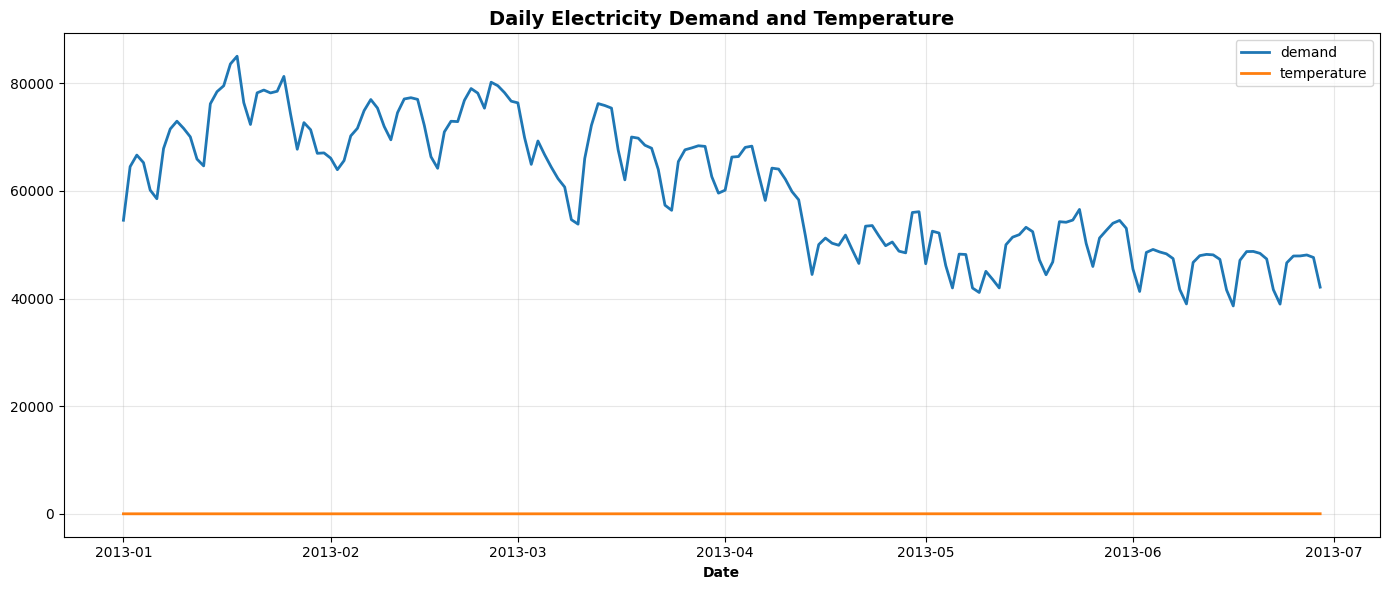

In [48]:
# plot_timeseries(): basic line plot for one or many columns.
plot_timeseries(electricity_daily[["demand", "temperature"]].head(180), title="Daily Electricity Demand and Temperature")


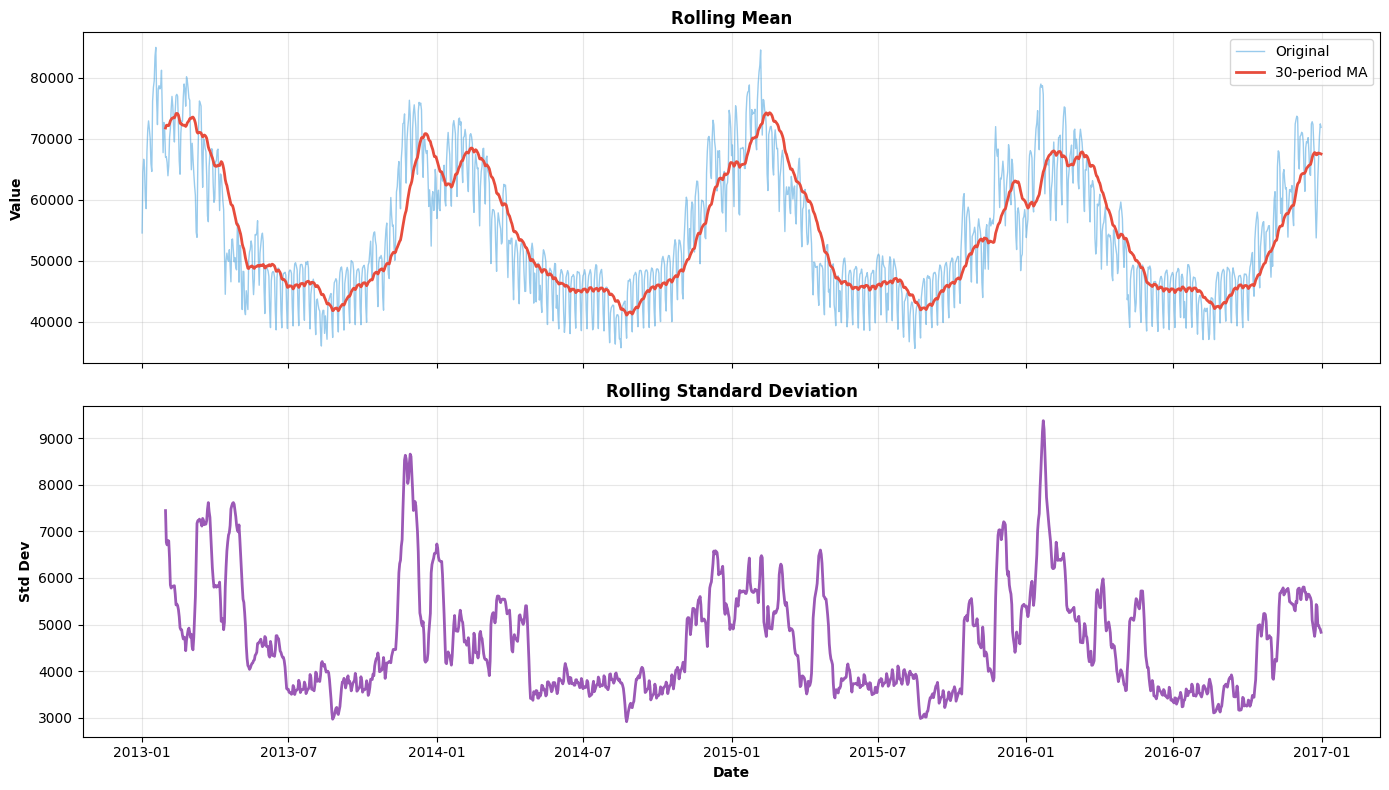

In [49]:
# plot_rolling_stats(): rolling mean and volatility in one view.
plot_rolling_stats(electricity_daily["demand"], window=30)


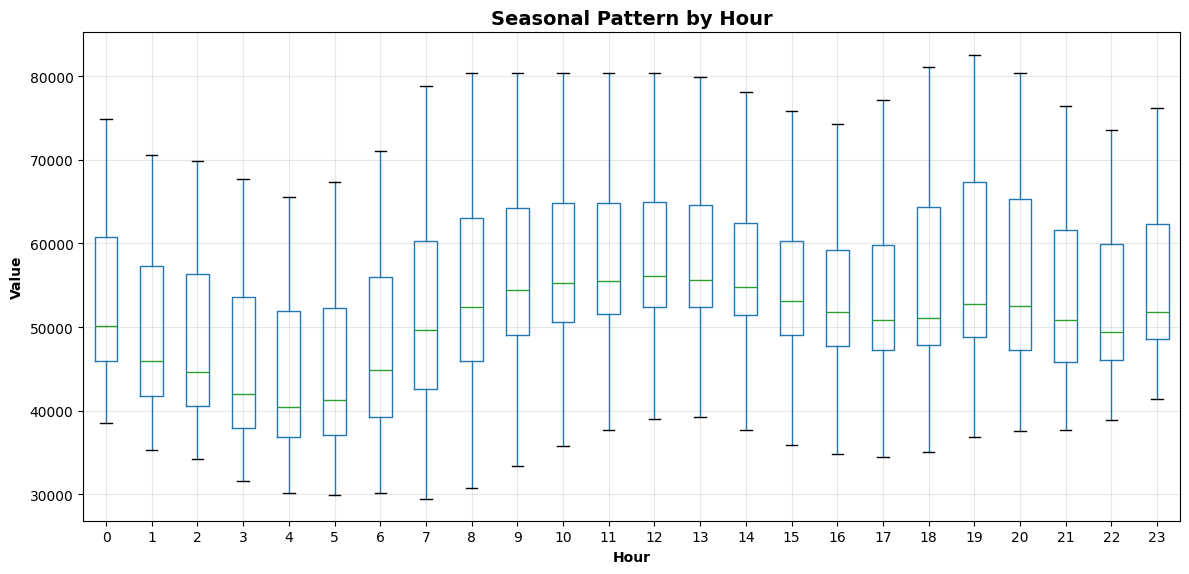

In [50]:
# plot_seasonal_pattern(): distribution by calendar bucket.
plot_seasonal_pattern(electricity["demand"].loc["2014"], freq="hour")


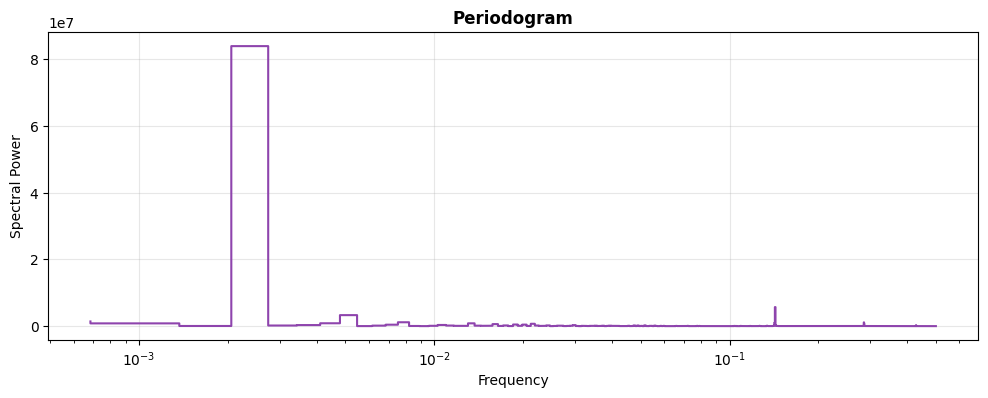

In [51]:
# plot_periodogram(): visual version of periodogram_spectrum().
ax = plot_periodogram(electricity_daily["demand"], sampling_rate=1.0)
plt.show()


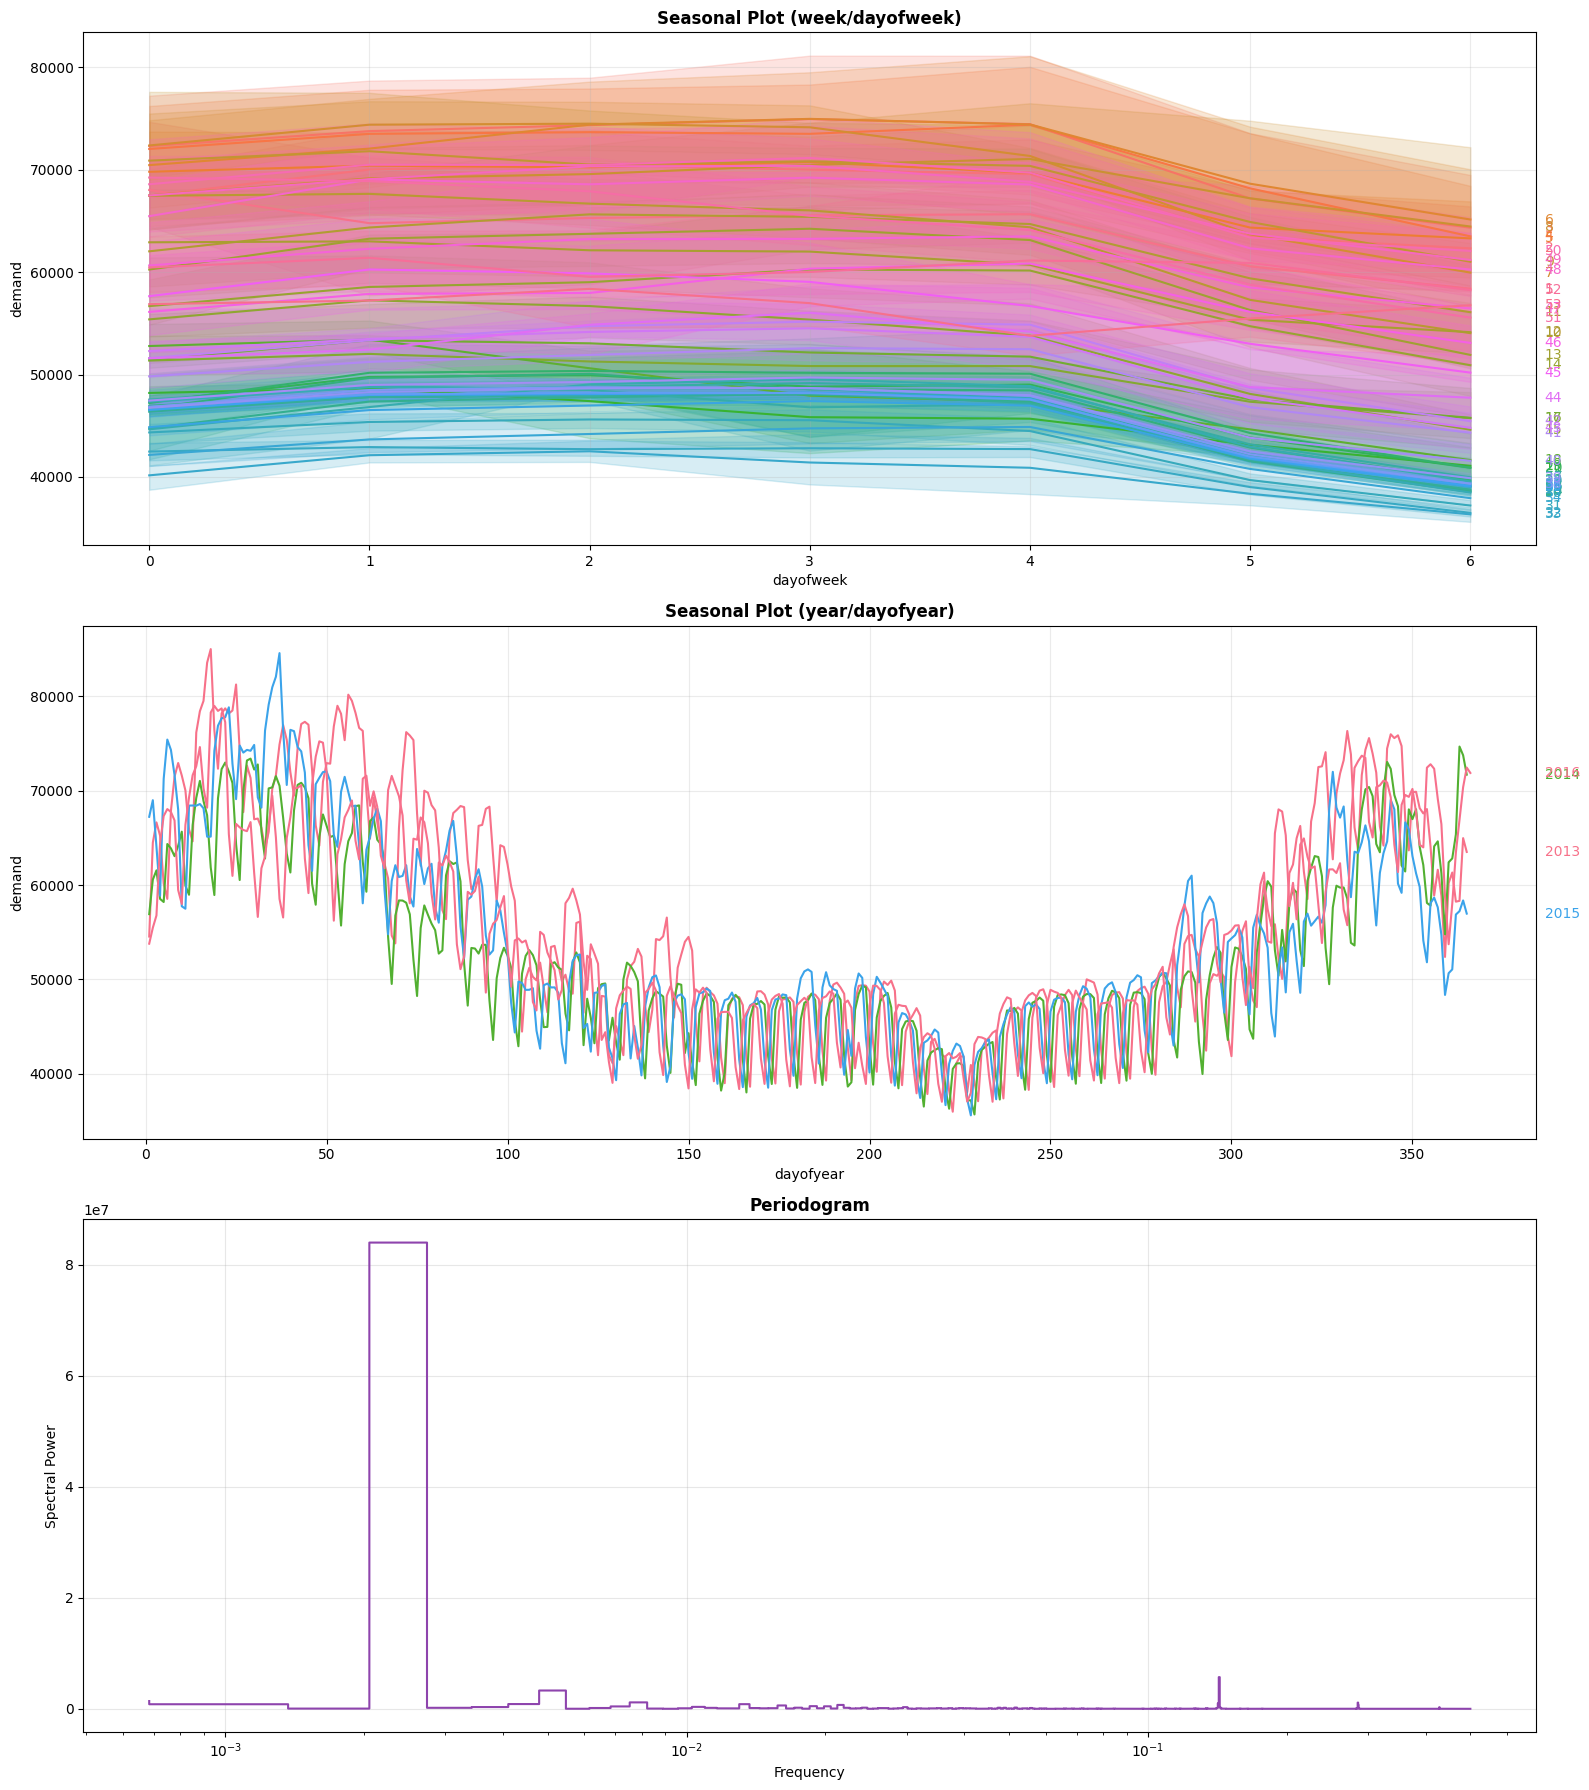

,demand,dayofweek,week,dayofyear,year
timestamp,,,,,
2013-01-01,54546.7500,1,1,1,2013
2013-01-02,64501.8125,2,1,2,2013
2013-01-03,66651.0625,3,1,3,2013
2013-01-04,65247.7500,4,1,4,2013
2013-01-05,60152.0000,5,1,5,2013


In [52]:
# plot_seasonality_dashboard(): weekly lines, annual lines, and periodogram together.
seasonality_input = electricity_daily.reset_index().rename(columns={"index": "date"})
seasonality_features, seasonality_fig = plot_seasonality_dashboard(
    seasonality_input,
    date_col=seasonality_input.columns[0],
    value_col="demand",
    frequency="D",
    sampling_rate=1.0,
)
plt.show()

seasonality_features.head()


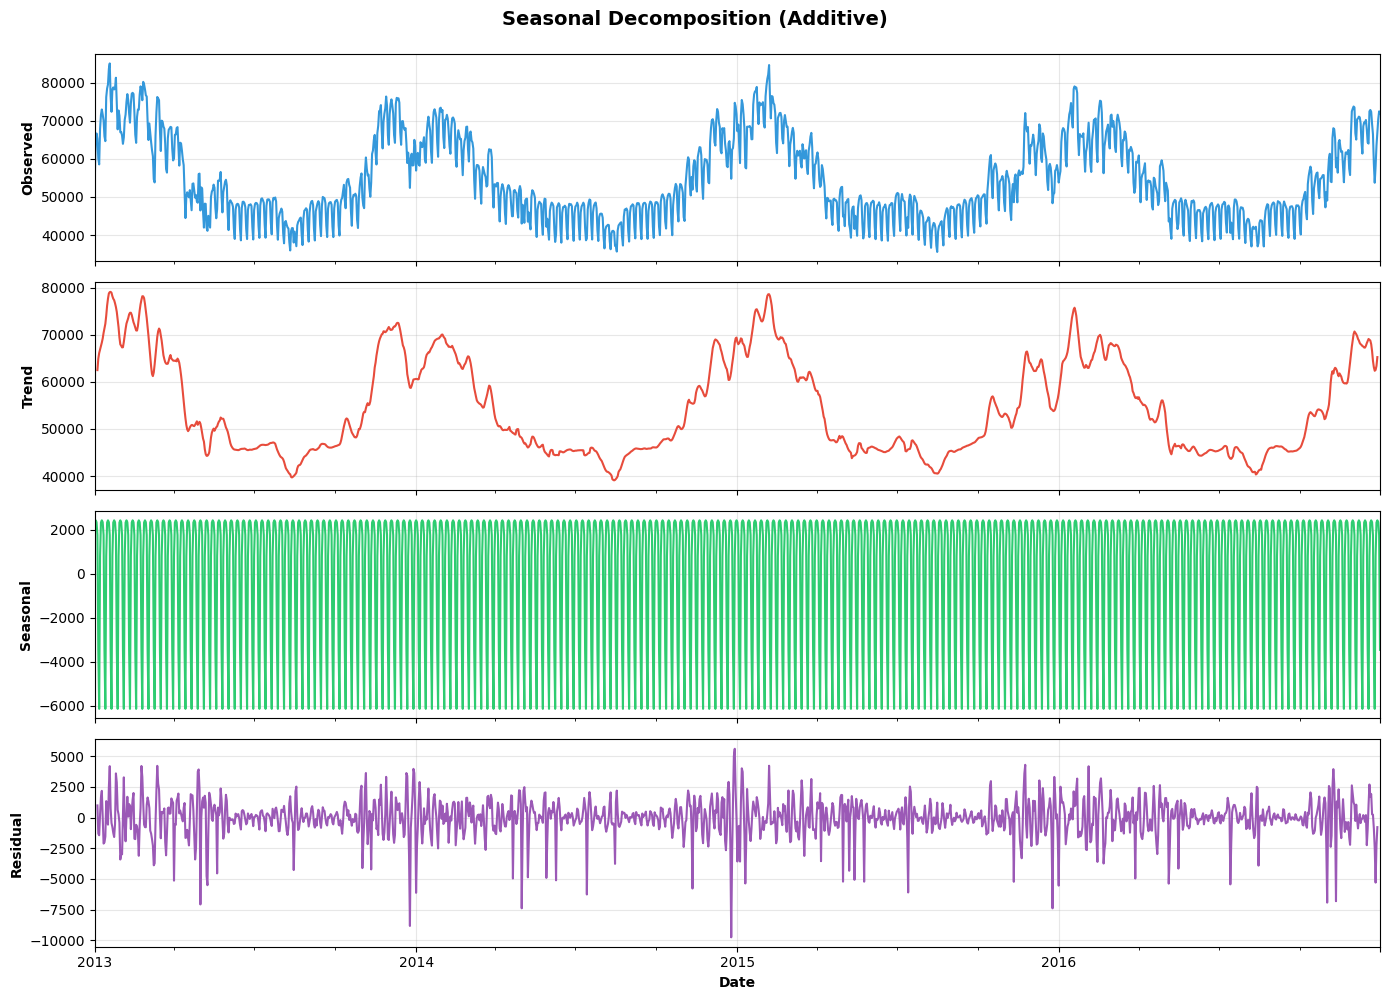

In [53]:
# plot_seasonal_decompose(): quick classical decomposition plot.
plot_seasonal_decompose(electricity_daily["demand"], period=7, model="additive")


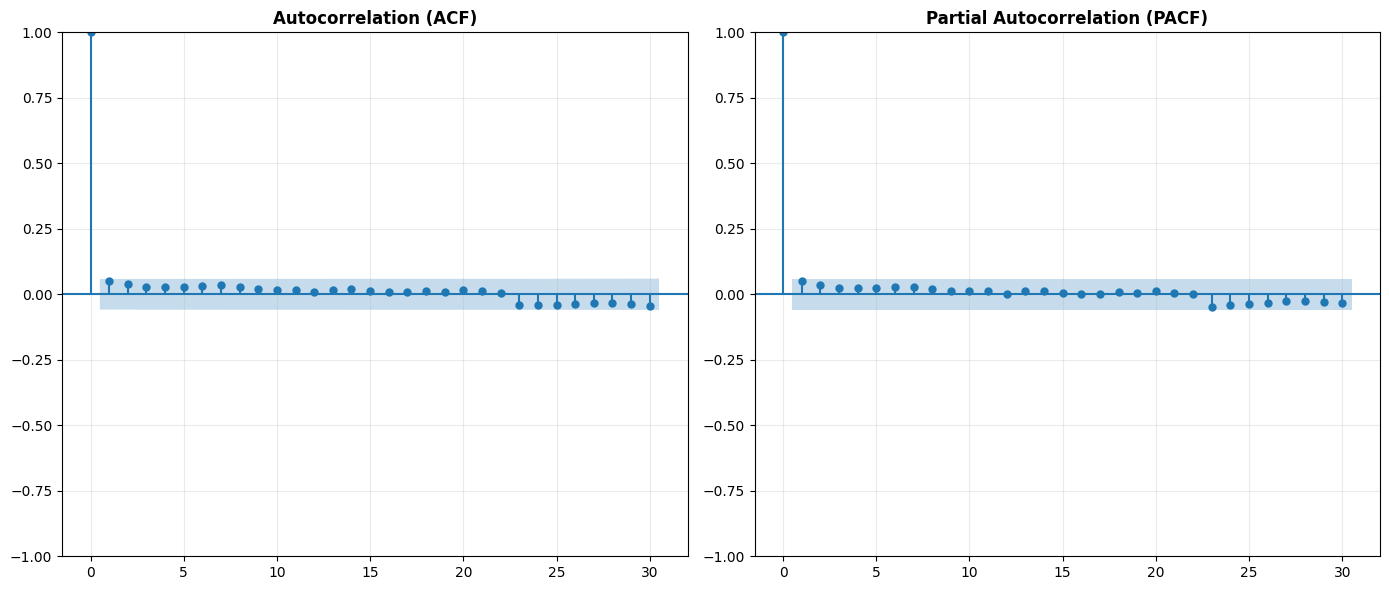

In [54]:
# plot_acf_pacf(): autocorrelation and partial autocorrelation for ARIMA thinking.
plot_acf_pacf(gold_diff, lags=30)


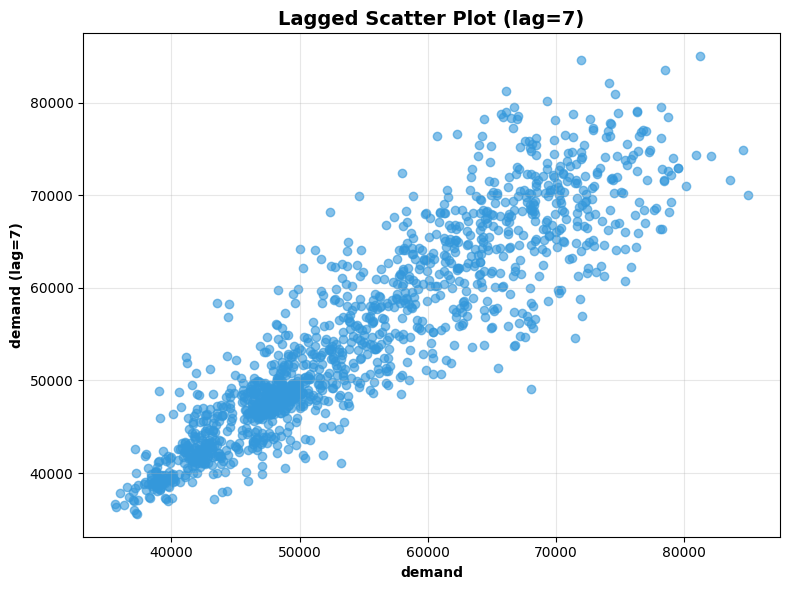

In [55]:
# plot_lagged_scatter(): inspect how strongly a value relates to a previous value.
plot_lagged_scatter(electricity_daily["demand"], lag=7)


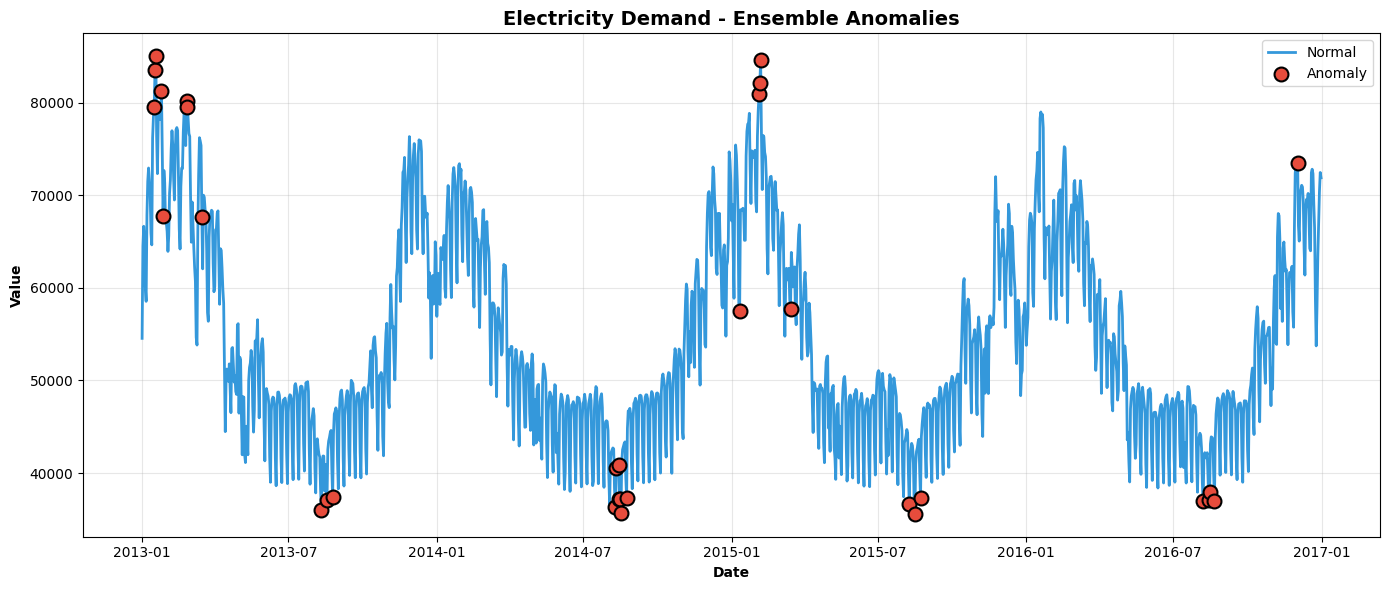

In [56]:
# plot_anomalies(): highlight boolean anomaly masks over the original series.
plot_anomalies(anomaly_series, ensemble_anomalies, title="Electricity Demand - Ensemble Anomalies")


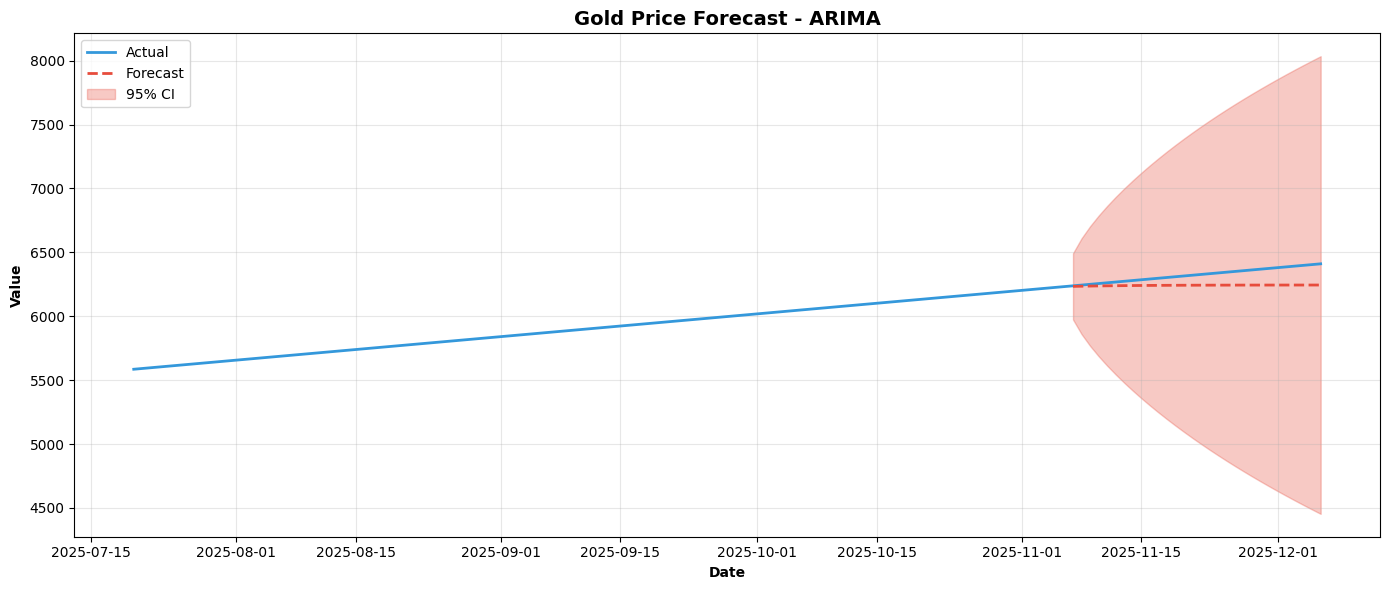

In [57]:
# plot_forecast(): actual history, forecast, and optional interval.
plot_forecast(
    actual=forecast_series.tail(140),
    forecast=arima_result.forecast,
    lower_bound=arima_result.lower_bound,
    upper_bound=arima_result.upper_bound,
    title="Gold Price Forecast - ARIMA",
)


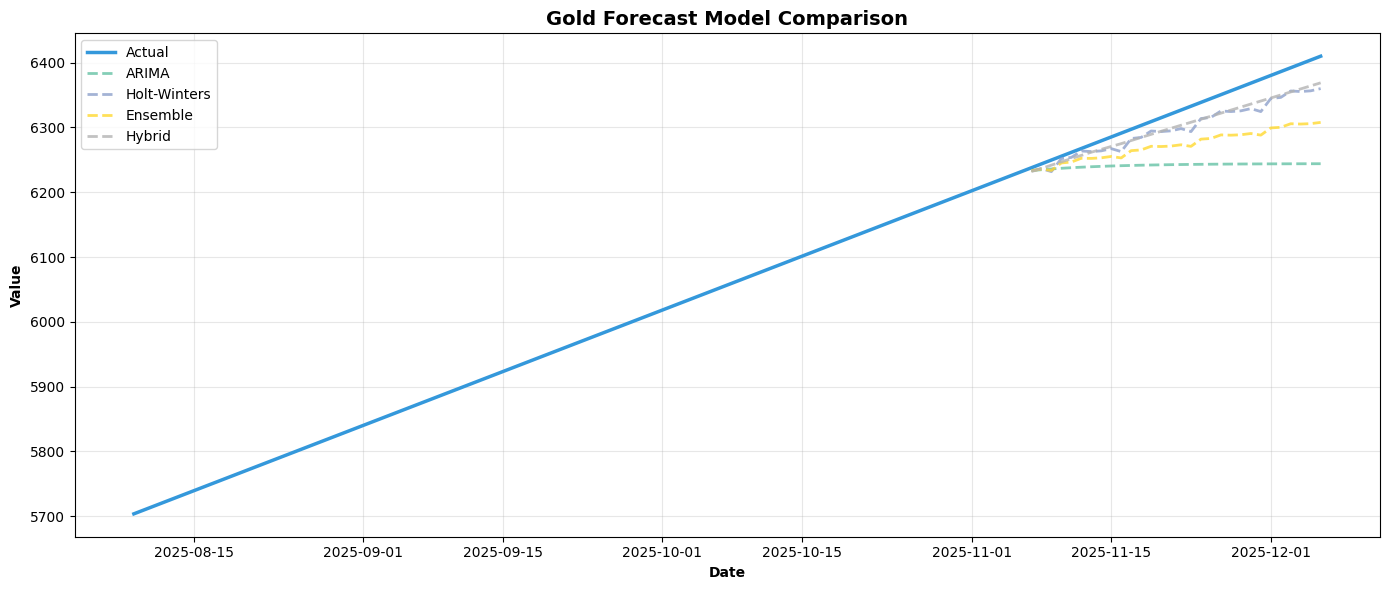

In [58]:
# plot_multiple_forecasts(): compare several forecast paths on the same chart.
plot_multiple_forecasts(
    forecast_series.tail(120),
    {
        "ARIMA": arima_result.forecast,
        "Holt-Winters": hw_result.forecast,
        "Ensemble": ensemble_forecast,
        "Hybrid": hybrid_result.forecast,
    },
    title="Gold Forecast Model Comparison",
)


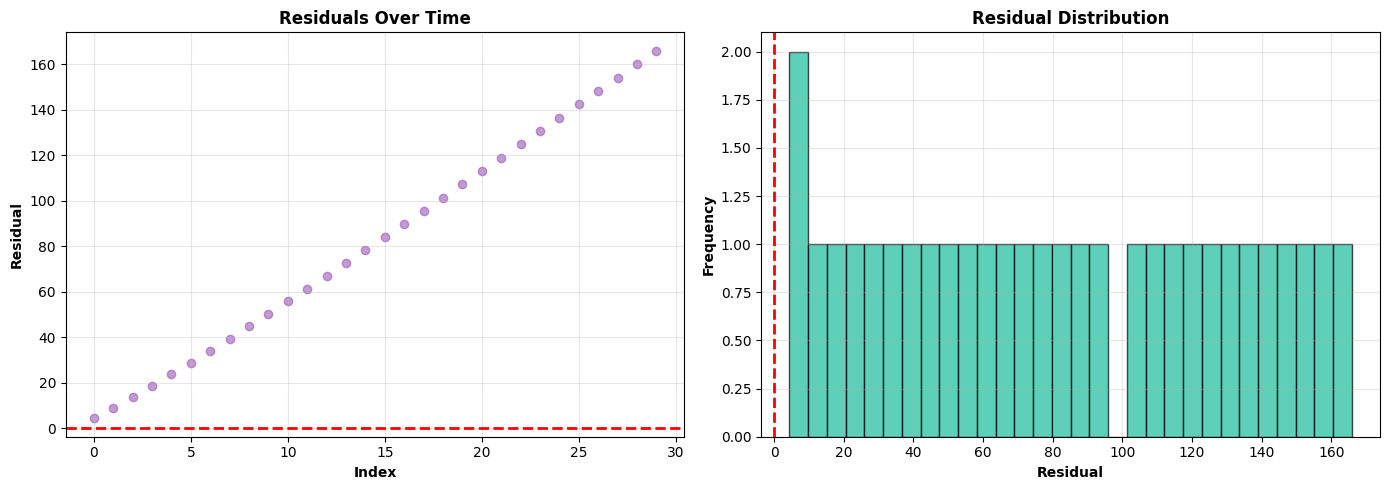

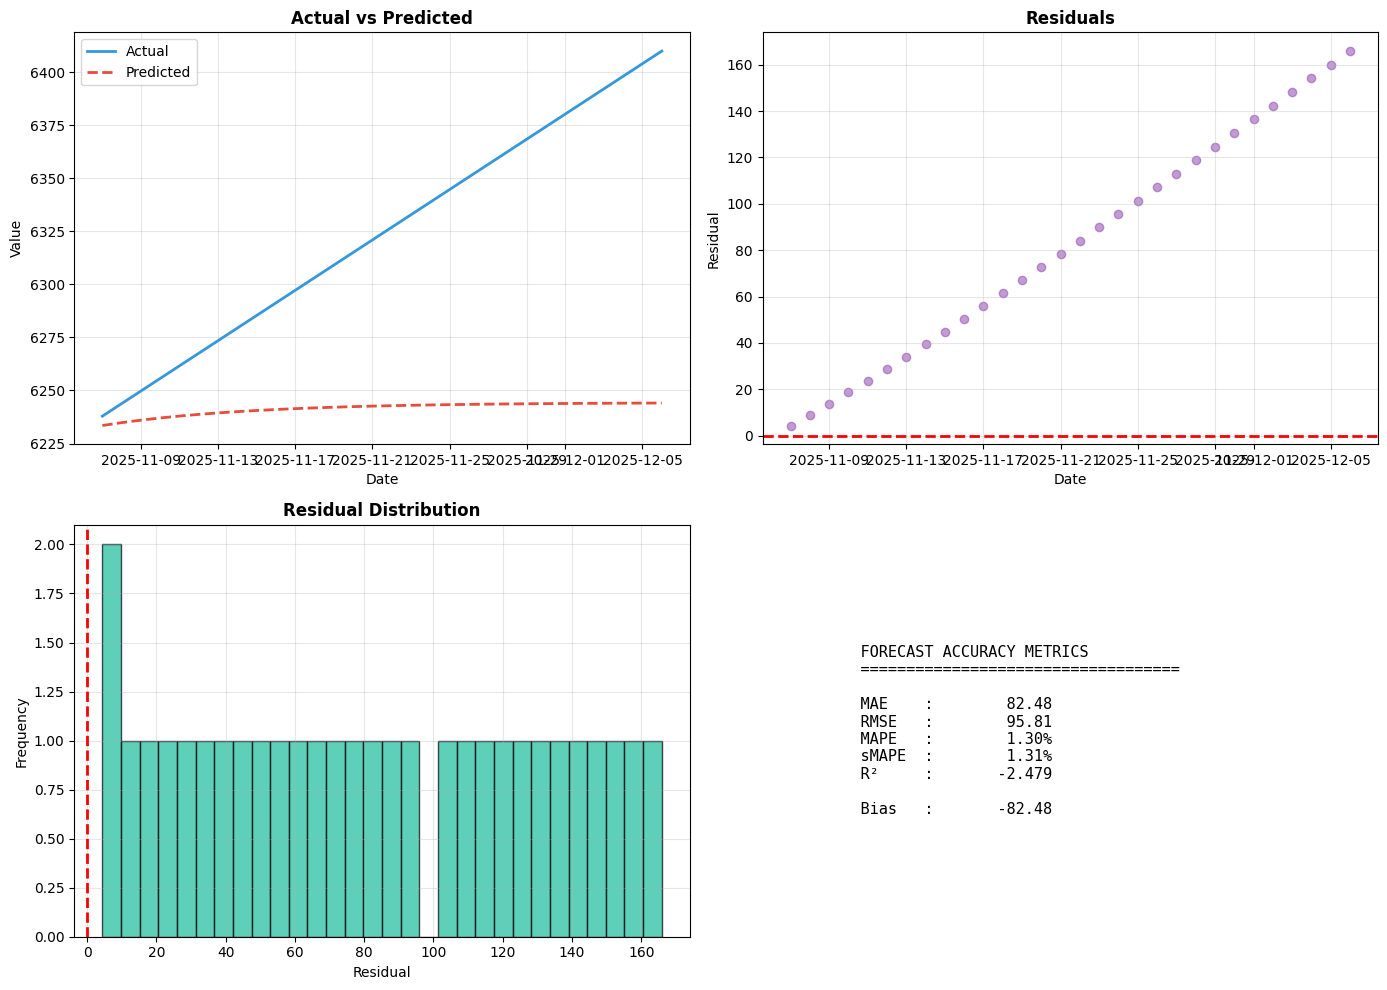

In [59]:
# plot_residuals() and plot_forecast_evaluation(): residual shape and metric summary.
plot_residuals(forecast_test, arima_result.forecast)
plot_forecast_evaluation(forecast_test, arima_result.forecast, dates=forecast_test.index)


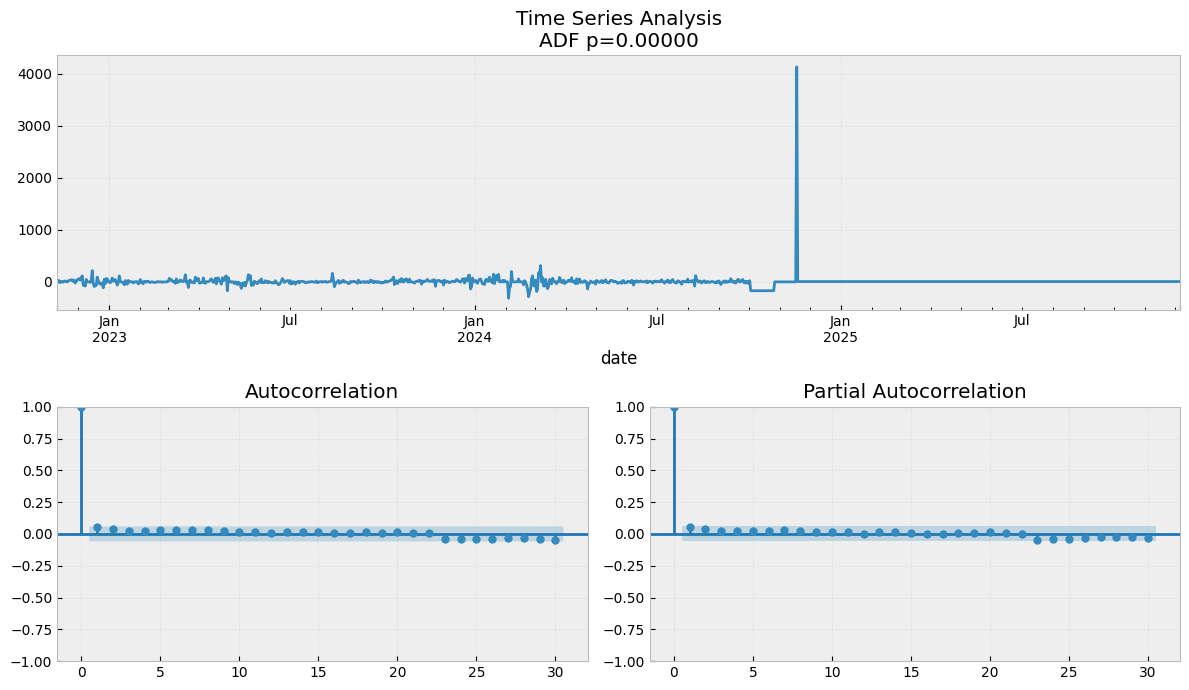

,gold_diff_adf
test,ADF
statistic,-31.790982
p_value,0.0
critical_values,"{'1%': -3.4361916433888267, '5%': -2.864119416..."
is_stationary,True
conclusion,stationary


In [60]:
# plot_time_series_diagnostics(): series + ACF/PACF + ADF p-value in one figure.
fig, stationarity = plot_time_series_diagnostics(gold_diff, lags=30)
plt.show()

pd.Series(stationarity).to_frame("gold_diff_adf")


## 11. Practical workflow checklist

For real work, a stable `MAna.timeseries` workflow usually looks like this:

1. Use `read_data()` and `DataCleaner` to get a reliable table.
2. Use `create_datetime_index()`, `validate_timeseries()`, and `detect_frequency()` before modeling.
3. Repair timestamp gaps with `fill_missing_timestamps()` and resample to the decision frequency.
4. Build features explicitly first, then use `auto_create_features()` once the target behavior is understood.
5. Split chronologically. If scaling is needed, use `chronological_split_and_scale()`.
6. Diagnose seasonality with periodograms, ACF/PACF, seasonal plots, and decomposition.
7. Start with simple forecasts, then compare richer models against the same holdout period.
8. Evaluate accuracy, bias, direction, and interval coverage.
9. Detect anomalies with multiple detectors and prefer an ensemble when false alerts are expensive.
10. Treat optional models as extras, not assumptions: Prophet, NeuralProphet, and AutoARIMA need their own dependencies.
